# Function 1D: Evolutionary optimization tutorial

Tutorial for **`docs_private/notes_and_references/evolutionary_methods_guide.md`**: optimize a **1D** synthetic function with **Genetic Algorithm (GA)** and **Evolution Strategy ((μ,λ)-ES)**.

- Same 1D example as `function_1D.ipynb`: domain \([0, 10]\), sinusoids + trend, multiple local optima.
- **GA:** real-valued, tournament selection, blend crossover, Gaussian mutation.
- **ES:** (μ,λ)-ES — mutation only; good for continuous space (guide, section 4).
- **BO:** GP surrogate + Expected Improvement (EI); sample-efficient comparison.
- **Concepts:** population, fitness, selection, variation; BO uses a GP surrogate.

## 1. Setup and imports

In [9]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import warnings

repo_root = Path.cwd()
for _ in range(5):
    if (repo_root / "src").exists(): break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

warnings.filterwarnings("ignore")

## 2. 1D synthetic function and parameters

**Same as `function_1D.ipynb`:** true function = sum of sinusoids + mild trend (multiple local optima). **Noise:** additive Gaussian on evaluations. Goal: **maximize** \(f(x)\).

In [10]:
# ==== 1D objective: sinusoids + trend (same as function_1D.ipynb) ====
def objective_1d(x):
    """Deterministic part on [0,10]. x: (n, 1) or (1,) or scalar. Returns (n,) or scalar."""
    x = np.asarray(x)
    if x.ndim == 0:
        x = np.atleast_1d(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    xx = x.ravel()
    v = (np.sin(xx / 2) + 0.5 * np.sin(1.3 * xx) + 0.3 * np.cos(xx / 1.7)) * 1.5 + 0.1 * xx + 1.5
    return v if v.size > 1 else float(np.asarray(v).flat[0])

def make_noisy_fun(fun, noise_std, seed=42):
    rng = np.random.default_rng(seed)
    def noisy(x):
        out = fun(x)
        arr = np.atleast_1d(np.asarray(out, dtype=float))
        arr = arr + noise_std * rng.standard_normal(arr.shape)
        return arr.ravel() if arr.size > 1 else float(arr.flat[0])
    return noisy

NOISE_STD = 0.15
true_function_1d = make_noisy_fun(objective_1d, NOISE_STD, seed=42)

# Bounds and EA parameters (see evolutionary_methods_guide.md)
bounds_1d = np.array([[0.0, 10.0]])
# Worst start: right boundary (poor region for this objective), so optimizers must climb from a bad initial point
x_start = np.array([10.0])
X_initial = x_start.reshape(1, 1)
# Keep iterating until solution: max budget (safety cap) and target (stop when best >= target)
true_max_approx = float(np.max(objective_1d(np.linspace(0, 10, 500).reshape(-1, 1))))  # deterministic max on fine grid
TARGET_Y = true_max_approx * 0.98   # stop when best_y >= TARGET_Y (within 2% of true max)
MAX_BUDGET = 400   # safety cap: stop after this many evaluations even if target not reached
N_QUERIES = MAX_BUDGET
POP_SIZE = 1
N_GENERATIONS = MAX_BUDGET
TOURNAMENT_SIZE = 2
MUTATION_SIGMA = 0.5
CROSSOVER_PROB = 0.7

# Grid for plotting (deterministic part)
n_plot = 200
x_plot = np.linspace(0, 10, n_plot).reshape(-1, 1)
y_true_plot = objective_1d(x_plot).ravel()

## 3. Minimal GA (evolutionary_methods_guide, section 3)

Tournament selection, blend crossover, Gaussian mutation.

### 3b. Evolution Strategy: \((\mu,\lambda)\)-ES

**ES** uses **mutation only**: sample \(\lambda\) offspring from a Gaussian around the current mean; keep best \(\mu\) to update the distribution. No crossover. See `evolutionary_methods_guide.md`, section 4.

In [11]:
# (μ,λ)-ES for 1D (same logic as 2D, works for any d)
def run_es_1d(fun, bounds, mu, lam, n_generations, sigma, seed=42, X_initial=None, target_y=None):
    """(μ,λ)-ES: sample λ from N(m, σ²I), evaluate, take best μ; m = weighted mean. Maximize fun. Stops early if target_y is set and best_y >= target_y."""
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None and len(X_initial) >= 1:
        m = np.mean(np.asarray(X_initial)[:5], axis=0)
    else:
        m = rng.uniform(bounds[:, 0], bounds[:, 1], size=d)
    best_y = -np.inf
    best_x = m.copy()
    history = []
    trajectory = [m.copy()]
    weights = np.log(mu + 1) - np.log(np.arange(1, mu + 1))
    weights = weights / weights.sum()
    for gen in range(n_generations):
        z = rng.standard_normal(size=(lam, d))
        pop = m + sigma * z
        pop = np.clip(pop, bounds[:, 0], bounds[:, 1])
        fitness = np.asarray(fun(pop)).ravel()
        idx = np.argsort(fitness)[::-1][:mu]
        top = pop[idx]
        m = np.average(top, axis=0, weights=weights)
        best_this_gen = float(fitness[idx[0]])
        if best_this_gen > best_y:
            best_y = best_this_gen
            best_x = pop[idx[0]].copy()
        history.append(best_y)
        trajectory.append(m.copy())
        if target_y is not None and best_y >= target_y:
            break
    return pop, fitness, best_x, best_y, history, trajectory

### 3c. Bayesian optimization (GP + EI)

Fit a **Gaussian process** on observed \((X, y)\), then choose the next point by maximizing **Expected Improvement (EI)**.

In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from src.optimizers.my_bayesian import expected_improvement

def run_bo_1d(fun, bounds, n_evaluations, n_initial=5, seed=42, X_initial=None, noise_std=0.15, target_y=None):
    """Bayesian optimization: GP surrogate + EI. Maximize fun. Returns (X, y, best_x, best_y, history). Stops early if target_y is set and best_y >= target_y."""
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None:
        X = np.asarray(X_initial)[:n_initial]
    else:
        X = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_initial, d))
    y = np.asarray(fun(X)).ravel()
    n_init_used = len(X)
    best_so_far = np.max(y)
    history = [best_so_far] * n_init_used
    kernel = (ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0))
              * RBF(length_scale=1.0, length_scale_bounds=(0.2, 5.0))
              + WhiteKernel(noise_level=noise_std**2, noise_level_bounds=(1e-6, 1.0)))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=4)
    n_opt = 200
    xi_ei = 0.04
    for _ in range(n_evaluations - n_init_used):
        gp.fit(X, y)
        X_cand = np.linspace(bounds[0, 0], bounds[0, 1], n_opt).reshape(-1, 1)
        mu, sigma_pred = gp.predict(X_cand, return_std=True)
        sigma_pred = np.maximum(sigma_pred, 1e-9)
        y_best = np.max(y)
        ei = expected_improvement(mu, sigma_pred, y_best, xi=xi_ei)
        i_best = np.argmax(ei)
        x_next = X_cand[i_best : i_best + 1]
        y_next = float(np.asarray(fun(x_next)).flat[0])
        X = np.vstack([X, x_next])
        y = np.append(y, y_next)
        best_so_far = max(best_so_far, y_next)
        history.append(best_so_far)
        if target_y is not None and best_so_far >= target_y:
            break
    best_idx = np.argmax(y)
    best_x = X[best_idx].copy()
    best_y = float(y[best_idx])
    return X, y, best_x, best_y, history

### 3d. Simulated annealing (baseline)

Single point; accept worse moves with probability \(\propto \exp(\Delta/T)\); \(T\) decreases.

In [13]:
def run_simulated_annealing_1d(fun, bounds, n_evaluations, sigma=0.5, T_start=0.5, seed=42, X_initial=None, target_y=None):
    """Simulated annealing: single point, Gaussian neighbour; accept worse with prob exp(Δ/T). Maximize fun. Stops early if target_y is set and best_y >= target_y."""
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None and len(X_initial) >= 1:
        X0 = np.asarray(X_initial)[:5]
        y0 = np.asarray(fun(X0)).ravel()
        x = X0[np.argmax(y0)].copy()
        y = float(np.max(y0))
        n_steps = n_evaluations - len(X0)
        history = [y] * len(X0)
    else:
        x = rng.uniform(bounds[:, 0], bounds[:, 1], size=d)
        y = float(np.asarray(fun(x.reshape(1, -1))).flat[0])
        n_steps = n_evaluations - 1
        history = [y]
    best_x, best_y = x.copy(), y
    trajectory = [x.copy()]
    for i in range(n_steps):
        T = T_start * (1 - (i + 1) / n_steps)
        x_new = x + sigma * rng.standard_normal(size=d)
        x_new = np.clip(x_new, bounds[:, 0], bounds[:, 1])
        y_new = float(np.asarray(fun(x_new.reshape(1, -1))).flat[0])
        delta = y_new - y
        if delta >= 0 or rng.random() < np.exp(delta / max(T, 1e-10)):
            x, y = x_new, y_new
        trajectory.append(x.copy())
        if y > best_y:
            best_x, best_y = x.copy(), y
        history.append(best_y)
        if target_y is not None and best_y >= target_y:
            break
    return np.array(trajectory), best_x, best_y, history

In [14]:
def select_tournament(pop, fitness, n_parents, k=2, rng=None):
    rng = rng or np.random.default_rng()
    n = len(pop)
    parents = []
    for _ in range(n_parents):
        idx = np.atleast_1d(rng.choice(n, size=min(k, n), replace=False))
        winner = idx[np.argmax(fitness[idx])]
        parents.append(pop[winner])
    return np.array(parents)

def crossover_blend(p1, p2, prob=0.7, rng=None):
    rng = rng or np.random.default_rng()
    if rng.random() > prob:
        return p1.copy()
    alpha = rng.random(size=p1.shape)
    return alpha * p1 + (1 - alpha) * p2

def mutate_gaussian(x, sigma, bounds, rng=None):
    rng = rng or np.random.default_rng()
    x = x + sigma * rng.standard_normal(size=x.shape)
    return np.clip(x, bounds[:, 0], bounds[:, 1])

def run_ga_1d(fun, bounds, pop_size, n_generations, sigma, crossover_prob, tournament_k, seed=42, X_initial=None, target_y=None):
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None and len(X_initial) >= 1:
        start = np.asarray(X_initial[0]).ravel()
        pop = start + sigma * rng.standard_normal(size=(pop_size, d))
        pop = np.clip(pop, bounds[:, 0], bounds[:, 1])
    else:
        pop = rng.uniform(bounds[:, 0], bounds[:, 1], size=(pop_size, d))
    fitness = np.atleast_1d(np.asarray(fun(pop)).ravel())
    best_y = float(np.max(fitness))
    best_x = pop[np.argmax(fitness)].copy()
    history = [best_y]
    start_pt = (np.asarray(X_initial[0]).ravel().copy() if (X_initial is not None and len(X_initial) >= 1) else best_x.copy())
    trajectory = [start_pt]
    for gen in range(n_generations - 1):
        parents = select_tournament(pop, fitness, n_parents=pop_size, k=tournament_k, rng=rng)
        offspring = []
        for i in range(0, pop_size, 2):
            p1, p2 = parents[i], parents[min(i + 1, pop_size - 1)]
            c1 = crossover_blend(p1, p2, prob=crossover_prob, rng=rng)
            c2 = crossover_blend(p2, p1, prob=crossover_prob, rng=rng)
            offspring.append(mutate_gaussian(c1, sigma, bounds, rng))
            offspring.append(mutate_gaussian(c2, sigma, bounds, rng))
        pop = np.array(offspring[:pop_size])
        fitness = np.atleast_1d(np.asarray(fun(pop)).ravel())
        if np.max(fitness) > best_y:
            best_y = float(np.max(fitness))
            best_x = pop[np.argmax(fitness)].copy()
        history.append(best_y)
        trajectory.append(best_x.copy())
        if target_y is not None and best_y >= target_y:
            break
    return pop, fitness, best_x, best_y, history, trajectory

## 4. Run and plot

In [15]:
# True max over plotting grid (deterministic)
true_max = float(np.max(y_true_plot))
true_min = float(np.min(y_true_plot))
x_max = float(x_plot[np.argmax(y_true_plot), 0])

# Run all methods (same query budget)
MU, LAM = 1, 1
N_BO_EVALS = N_QUERIES
# Run until solution found (best_y >= TARGET_Y) or MAX_BUDGET reached
pop_1d, fit_1d, best_x_ga, best_y_ga, history_ga, trajectory_ga = run_ga_1d(
    true_function_1d, bounds_1d, POP_SIZE, N_GENERATIONS,
    MUTATION_SIGMA, CROSSOVER_PROB, TOURNAMENT_SIZE, seed=42, X_initial=X_initial, target_y=TARGET_Y)
_, _, best_x_es, best_y_es, history_es, trajectory_es = run_es_1d(
    true_function_1d, bounds_1d, MU, LAM, N_GENERATIONS, MUTATION_SIGMA, seed=42, X_initial=X_initial, target_y=TARGET_Y)
X_bo, _, best_x_bo, best_y_bo, history_bo = run_bo_1d(
    true_function_1d, bounds_1d, N_BO_EVALS, n_initial=5, seed=42, X_initial=X_initial, noise_std=NOISE_STD, target_y=TARGET_Y)
trajectory_sa, best_x_sa, best_y_sa, history_sa = run_simulated_annealing_1d(
    true_function_1d, bounds_1d, N_QUERIES, sigma=0.5, T_start=0.3, seed=42, X_initial=X_initial, target_y=TARGET_Y)

queries_ga = len(history_ga) * POP_SIZE
queries_es = len(history_es) * LAM
queries_bo = len(history_bo)
queries_sa = len(history_sa)
denom = max(true_max, 1e-10)
err_ga = 100 * (true_max - np.array(history_ga)) / denom
err_es = 100 * (true_max - np.array(history_es)) / denom
err_bo = 100 * (true_max - np.array(history_bo)) / denom
err_sa = 100 * (true_max - np.array(history_sa)) / denom

print("True max:", f"y={true_max:.4f}", f"at x={x_max:.3f}")
print("Method   |  Steps  | Queries | Final err %")
print("---------|--------|--------|------------")
print(f"GA       | {len(history_ga):6} | {queries_ga:6} | {err_ga[-1]:.2f}%")
print(f"ES       | {len(history_es):6} | {queries_es:6} | {err_es[-1]:.2f}%")
print(f"BO       | {len(history_bo):6} | {queries_bo:6} | {err_bo[-1]:.2f}%")
print(f"SA       | {len(history_sa):6} | {queries_sa:6} | {err_sa[-1]:.2f}%")


True max: y=3.6574 at x=1.558
Method   |  Steps  | Queries | Final err %
---------|--------|--------|------------
GA       |    300 |    300 | -0.21%
ES       |    153 |    153 | -3.80%
BO       |      6 |      6 | -0.91%
SA       |    400 |    400 | 40.37%


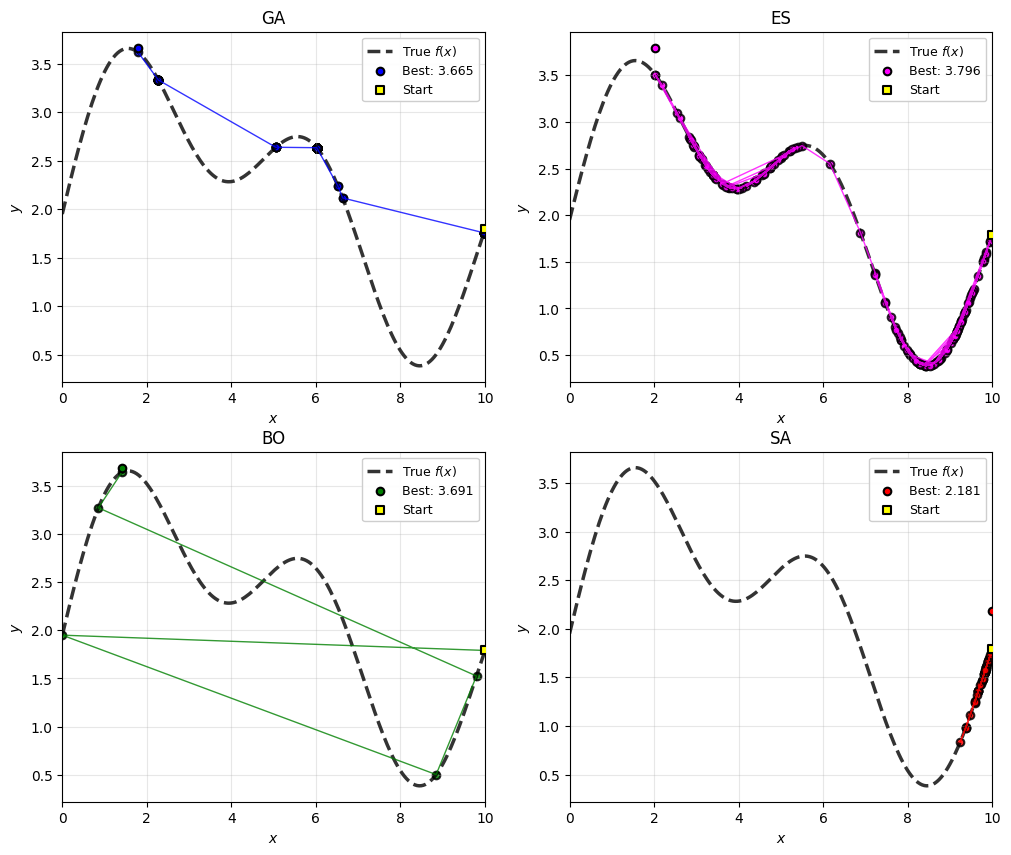

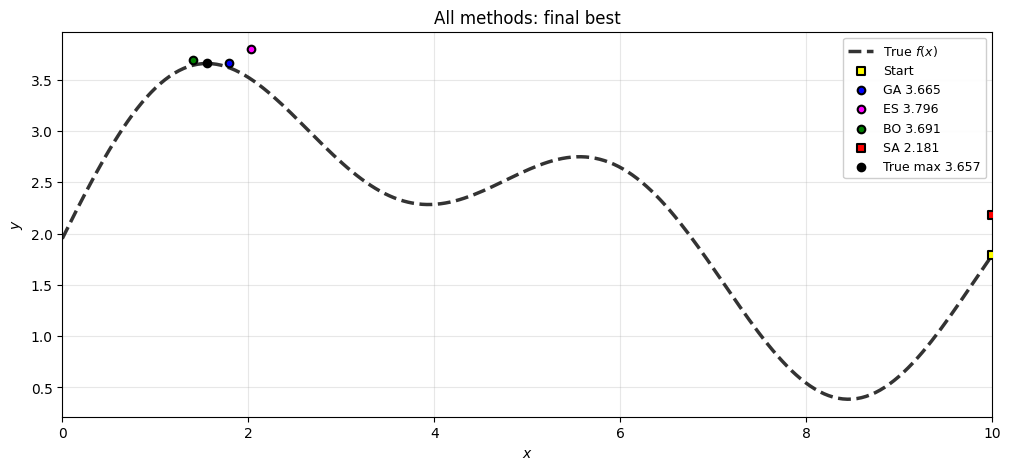

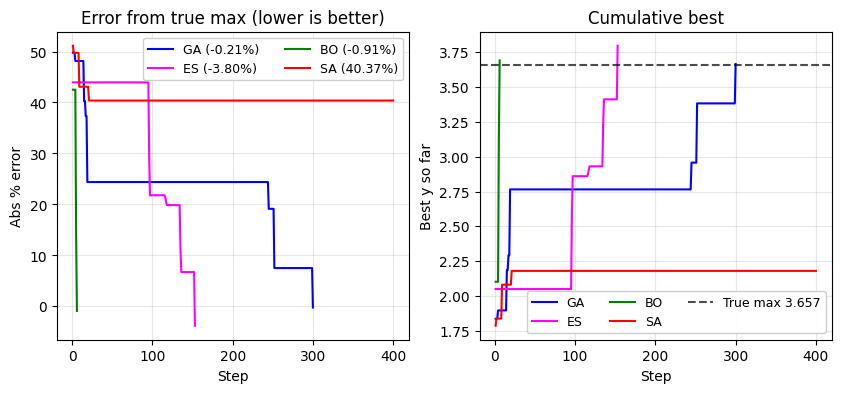

In [19]:
# 1D: true function + trajectories (aesthetics aligned with notebooks/function_1_Radiation-Detection.ipynb)
SCATTER_EDGE_LW = 1.5
LEGEND_FONTSIZE = 9
LEGEND_LOC = "upper right"
LEGEND_FRAMEALPHA = 0.95

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
x_flat = x_plot.ravel()

def plot_1d_trajectory(ax, trajectory, best_x, best_y, color, title, x_start=None):
    ax.plot(x_flat, y_true_plot, "k--", alpha=0.8, lw=2.5, label="True $f(x)$")
    tr = np.asarray(trajectory).reshape(-1, 1)
    tr_flat = tr.ravel()
    ax.plot(tr_flat, objective_1d(tr).ravel(), color=color, lw=1, alpha=0.8)
    ax.scatter(tr_flat, objective_1d(tr).ravel(), c=color, s=30, alpha=0.85, edgecolors="k", linewidths=SCATTER_EDGE_LW)
    ax.scatter(best_x.ravel(), [best_y], c=color, s=30, marker="o", edgecolors="black", linewidths=SCATTER_EDGE_LW, zorder=5, label=f"Best: {best_y:.3f}")
    if x_start is not None:
        ax.scatter(x_start.ravel(), np.atleast_1d(objective_1d(x_start)).ravel(), c="yellow", s=30, marker="s", edgecolors="black", linewidths=SCATTER_EDGE_LW, zorder=6, label="Start")
    ax.set_xlabel("$x$", fontsize=10)
    ax.set_ylabel("$y$", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 10)
    ax.legend(loc=LEGEND_LOC, fontsize=LEGEND_FONTSIZE, framealpha=LEGEND_FRAMEALPHA)
    ax.grid(True, alpha=0.3)

plot_1d_trajectory(axes[0], trajectory_ga, best_x_ga, best_y_ga, "blue", "GA", x_start=x_start)
plot_1d_trajectory(axes[1], trajectory_es, best_x_es, best_y_es, "magenta", "ES", x_start=x_start)
plot_1d_trajectory(axes[2], X_bo, best_x_bo, best_y_bo, "green", "BO", x_start=x_start)
plot_1d_trajectory(axes[3], trajectory_sa, best_x_sa, best_y_sa, "red", "SA", x_start=x_start)
plt.show()

# All best points on one plot
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 5))
ax2.plot(x_flat, y_true_plot, "k--", alpha=0.8, lw=2.5, label="True $f(x)$")
ax2.scatter(x_start.ravel(), np.atleast_1d(objective_1d(x_start)).ravel(), c="yellow", s=30, marker="s", edgecolors="black", linewidths=SCATTER_EDGE_LW, zorder=6, label="Start")
ax2.scatter(best_x_ga.ravel(), [best_y_ga], c="blue", s=30, marker="o", edgecolors="k", linewidths=SCATTER_EDGE_LW, zorder=5, label=f"GA {best_y_ga:.3f}")
ax2.scatter(best_x_es.ravel(), [best_y_es], c="magenta", s=30, marker="o", edgecolors="k", linewidths=SCATTER_EDGE_LW, zorder=5, label=f"ES {best_y_es:.3f}")
ax2.scatter(best_x_bo.ravel(), [best_y_bo], c="green", s=30, marker="o", edgecolors="k", linewidths=SCATTER_EDGE_LW, zorder=5, label=f"BO {best_y_bo:.3f}")
ax2.scatter(best_x_sa.ravel(), [best_y_sa], c="red", s=30, marker="s", edgecolors="k", linewidths=SCATTER_EDGE_LW, zorder=5, label=f"SA {best_y_sa:.3f}")
ax2.scatter([x_max], [true_max], c="black", s=30, marker="o", edgecolors="k", linewidths=SCATTER_EDGE_LW, zorder=5, label=f"True max {true_max:.3f}")
ax2.set_xlabel("$x$", fontsize=10)
ax2.set_ylabel("$y$", fontsize=10)
ax2.set_title("All methods: final best", fontsize=12)
ax2.set_xlim(0, 10)
ax2.legend(loc=LEGEND_LOC, fontsize=LEGEND_FONTSIZE, framealpha=LEGEND_FRAMEALPHA)
ax2.grid(True, alpha=0.3)
plt.show()

# Error over time (same line/marker style as Radiation-Detection convergence plots)
fig3, ax3 = plt.subplots(1, 2, figsize=(10, 4))
# Each method may stop early (different history lengths), so use per-method step indices
steps_ga = np.arange(1, len(err_ga) + 1, dtype=float)
steps_es = np.arange(1, len(err_es) + 1, dtype=float)
steps_bo = np.arange(1, len(err_bo) + 1, dtype=float)
steps_sa = np.arange(1, len(err_sa) + 1, dtype=float)
ax3[0].plot(steps_ga, err_ga, '-', color='blue', markersize=5, markerfacecolor='w', markeredgecolor='blue', markeredgewidth=1.5, label=f'GA ({err_ga[-1]:.2f}%)')
ax3[0].plot(steps_es, err_es, '-', color='magenta', markersize=5, markerfacecolor='w', markeredgecolor='magenta', markeredgewidth=1.5, label=f'ES ({err_es[-1]:.2f}%)')
ax3[0].plot(steps_bo, err_bo, '-', color='green', markersize=5, markerfacecolor='w', markeredgecolor='green', markeredgewidth=1.5, label=f'BO ({err_bo[-1]:.2f}%)')
ax3[0].plot(steps_sa, err_sa, '-', color='red', markersize=5, markerfacecolor='w', markeredgecolor='red', markeredgewidth=1.5, label=f'SA ({err_sa[-1]:.2f}%)')
ax3[0].set_xlabel('Step')
ax3[0].set_ylabel('Abs % error')
ax3[0].set_title('Error from true max (lower is better)')
ax3[0].legend(ncol=2, fontsize=LEGEND_FONTSIZE, framealpha=LEGEND_FRAMEALPHA)
ax3[0].grid(True, alpha=0.3)
# Cumulative best y (aligned with Radiation-Detection "Cumulative best" panel)
best_so_far_ga = np.maximum.accumulate(np.array(history_ga))
best_so_far_es = np.maximum.accumulate(np.array(history_es))
best_so_far_bo = np.maximum.accumulate(np.array(history_bo))
best_so_far_sa = np.maximum.accumulate(np.array(history_sa))
ax3[1].plot(steps_ga, best_so_far_ga, '-', color='blue', markersize=5, markerfacecolor='w', markeredgecolor='blue', markeredgewidth=1.5, label='GA')
ax3[1].plot(steps_es, best_so_far_es, '-', color='magenta', markersize=5, markerfacecolor='w', markeredgecolor='magenta', markeredgewidth=1.5, label='ES')
ax3[1].plot(steps_bo, best_so_far_bo, '-', color='green', markersize=5, markerfacecolor='w', markeredgecolor='green', markeredgewidth=1.5, label='BO')
ax3[1].plot(steps_sa, best_so_far_sa, '-', color='red', markersize=5, markerfacecolor='w', markeredgecolor='red', markeredgewidth=1.5, label='SA')
ax3[1].axhline(true_max, color='black', linestyle='--', lw=1.5, alpha=0.7, label=f'True max {true_max:.3f}')
ax3[1].set_xlabel('Step')
ax3[1].set_ylabel('Best y so far')
ax3[1].set_title('Cumulative best')
ax3[1].legend(ncol=3, fontsize=LEGEND_FONTSIZE, framealpha=LEGEND_FRAMEALPHA)
ax3[1].grid(True, alpha=0.3)
plt.show()


## 5. Summary (evolutionary methods guide)

| Concept | GA | (μ,λ)-ES | BO (GP+EI) |
|--------|-----|----------|------------|
| **Population / evals** | 1/gen | λ=1/gen | Until solution or max budget |
| **Surrogate** | None | None | GP (RBF) |
| **Next point** | Selection + crossover + mutation | Best μ → new mean | argmax EI |
| **Efficiency** | Many evals/gen | Many evals/gen | Few evals (sample-efficient) |

For BBO (one query per week): use observed \((X,y)\) as population and/or a surrogate to score offspring, or **Nevergrad** (CMA-ES)—see `evolutionary_methods_guide.md`, section 6.